In [1]:
# cna_prediction_metrics.ipynb - plot metrics (AUROC and AUPRC) of CNA prediction.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from matplotlib.patches import Patch

In [3]:
root_dir = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/cna_prediction/1r1n1t/vary_tumor_prop'
out_dir = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/cna_prediction/1r1n1t/vary_tumor_prop/analysis/cna_prediction/calicost'
with_ref = 'calicost'

## Merge metrics from multiple experiments into one single file.

In [4]:
run_id_list = sorted([d for d in os.listdir(root_dir) if d.endswith('t') and d != '997n3t'])
run_id_list

['100n900t',
 '10n990t',
 '300n700t',
 '30n970t',
 '500n500t',
 '700n300t',
 '900n100t',
 '970n30t',
 '990n10t']

In [5]:
dat = None
for run_id in run_id_list:
    print("processing '%s' ..." % run_id)
    run_dir = os.path.join(root_dir, run_id)
    df_run = None
    for cna_type in ('gain', 'loss', 'loh'):
        df2 = None
        for metric in ('auroc', 'auprc'):
            metric_fn = os.path.join(run_dir, 'cna_prediction/%s/%s/2_metric/metric.%s.%s.tsv' % \
                                    (with_ref, cna_type, cna_type, metric))
            if not os.path.exists(metric_fn):
                print("[W] file '%s' does not exist!" % metric_fn)
                continue
            df1 = pd.read_csv(metric_fn, sep = '\t')
            if df2 is None:
                df2 = df1
            else:
                assert np.all(df2['tool'] == df1['tool'])
                df2 = df2.merge(df1, on = 'tool', how = 'left')
        if df2 is None:
            continue
        df2['cna_type'] = cna_type
        if df_run is None:
            df_run = df2
        else:
            df_run = pd.concat([df_run, df2], ignore_index = True)
    if df_run is None:
        continue
    df_run['run_id'] = run_id
    if dat is None:
        dat = df_run
    else:
        dat = pd.concat([dat, df_run], ignore_index = True)
    print("dat shape: %s" % str(dat.shape))
dat.head()

processing '100n900t' ...
dat shape: (9, 5)
processing '10n990t' ...
dat shape: (15, 5)
processing '300n700t' ...
dat shape: (24, 5)
processing '30n970t' ...
dat shape: (30, 5)
processing '500n500t' ...
dat shape: (39, 5)
processing '700n300t' ...
dat shape: (48, 5)
processing '900n100t' ...
dat shape: (51, 5)
processing '970n30t' ...
dat shape: (54, 5)
processing '990n10t' ...
dat shape: (57, 5)


,tool,AUROC,AUPRC,cna_type,run_id
0,CalicoST_ref_purity,0.993819,0.981052,gain,100n900t
1,CalicoST_noref_purity,0.957492,0.967939,gain,100n900t
2,CalicoST_noref_nopurity,0.985483,0.976437,gain,100n900t
3,CalicoST_ref_purity,0.936329,0.932741,loss,100n900t
4,CalicoST_noref_purity,0.856672,0.873985,loss,100n900t


In [6]:
dat['tool'] = dat['tool'].str.removeprefix('CalicoST_')
dat.head()

,tool,AUROC,AUPRC,cna_type,run_id
0,ref_purity,0.993819,0.981052,gain,100n900t
1,noref_purity,0.957492,0.967939,gain,100n900t
2,noref_nopurity,0.985483,0.976437,gain,100n900t
3,ref_purity,0.936329,0.932741,loss,100n900t
4,noref_purity,0.856672,0.873985,loss,100n900t


In [7]:
metric_fn = os.path.join(out_dir, 'cna_prediction.%s.metrics.tsv' % with_ref)
dat.to_csv(
    metric_fn,
    sep = '\t',
    index = False
)

In [8]:
dat.head()

,tool,AUROC,AUPRC,cna_type,run_id
0,ref_purity,0.993819,0.981052,gain,100n900t
1,noref_purity,0.957492,0.967939,gain,100n900t
2,noref_nopurity,0.985483,0.976437,gain,100n900t
3,ref_purity,0.936329,0.932741,loss,100n900t
4,noref_purity,0.856672,0.873985,loss,100n900t


## Plot

In [9]:
dat = pd.read_csv(
    metric_fn,
    sep = '\t'
)
dat.head()

,tool,AUROC,AUPRC,cna_type,run_id
0,ref_purity,0.993819,0.981052,gain,100n900t
1,noref_purity,0.957492,0.967939,gain,100n900t
2,noref_nopurity,0.985483,0.976437,gain,100n900t
3,ref_purity,0.936329,0.932741,loss,100n900t
4,noref_purity,0.856672,0.873985,loss,100n900t


In [10]:
dat['run_id_raw'] = dat['run_id']
dat['run_id'] = dat['run_id'].map({
    '10n990t':'99',
    '30n970t':'97',
    '100n900t':'90',
    '300n700t':'70',
    '500n500t':'50',
    '700n300t':'30',
    '900n100t':'10',
    '970n30t':'3',
    '990n10t':'1'
})
dat['run_id'] = pd.Categorical(
    dat['run_id'], 
    categories = [str(i) for i in (1, 3, 10, 30, 50, 70, 90, 97, 99)],
    ordered = True
)
dat.head()

,tool,AUROC,AUPRC,cna_type,run_id,run_id_raw
0,ref_purity,0.993819,0.981052,gain,90,100n900t
1,noref_purity,0.957492,0.967939,gain,90,100n900t
2,noref_nopurity,0.985483,0.976437,gain,90,100n900t
3,ref_purity,0.936329,0.932741,loss,90,100n900t
4,noref_purity,0.856672,0.873985,loss,90,100n900t


In [11]:
dat['tool'] = dat['tool'].map({
    'ref_purity': 'ref(+)/purity(+)',
    'noref_purity': 'ref(-)/purity(+)',
    'noref_nopurity': 'ref(-)/purity(-)'
})
dat['tool'] = pd.Categorical(
    dat['tool'], 
    categories = ['ref(-)/purity(-)', 'ref(-)/purity(+)', 'ref(+)/purity(+)'],
    ordered = True
)
dat.head()

,tool,AUROC,AUPRC,cna_type,run_id,run_id_raw
0,ref(+)/purity(+),0.993819,0.981052,gain,90,100n900t
1,ref(-)/purity(+),0.957492,0.967939,gain,90,100n900t
2,ref(-)/purity(-),0.985483,0.976437,gain,90,100n900t
3,ref(+)/purity(+),0.936329,0.932741,loss,90,100n900t
4,ref(-)/purity(+),0.856672,0.873985,loss,90,100n900t


In [12]:
def plot_metrics(df, metric, figsize = (9, 5), fontsize = 10):
    """Plot a grouped stacked bar chart of metric values.
    
    Parameters:
    ----------
    df : pd.DataFrame
        Must contain columns: 'tool', 'AUROC', 'cna_type', 'run_id'.
        'cna_type' should have values: 'gain', 'loss', 'loh'.
    metric : {'AUROC', 'AUPRC'}
    figsize : tuple, optional
        Figure size (width, height). Default is (9, 5).
    
    Returns:
    -------
    fig, ax : matplotlib figure and axes
    """
    required_cols = {'tool', metric, 'cna_type', 'run_id'}
    if not required_cols.issubset(df.columns):
        raise ValueError(f"DataFrame must contain columns: {required_cols}")
    
    if not set(df['cna_type'].unique()).issubset({'gain', 'loss', 'loh'}):
        raise ValueError("cna_type must only contain 'gain', 'loss', 'loh'")
    
    # Ensure consistent ordering
    df = df.copy()
    df['cna_type'] = pd.Categorical(df['cna_type'], categories = ['gain', 'loss', 'loh'])
    df = df.sort_values(['run_id', 'tool', 'cna_type']).reset_index(drop = True)

    # Pivot to get metric value per (run_id, tool, cna_type)
    pivot = df.pivot_table(
        index = ['run_id', 'tool'],
        columns = 'cna_type',
        values = metric,
        fill_value = 0
    )

    # Extract unique groups
    run_ids = pivot.index.get_level_values('run_id').unique()
    tools = df['tool'].cat.categories.tolist()
    n_runs, n_tools = len(run_ids), len(tools)

    # Bar layout
    bar_width = 0.65 / n_tools
    x_centers = np.arange(n_runs)

    # Colors
    stack_colors = {'gain': '#D14050', 'loss': '#0078BB', 'loh': '#40B5A8'}
    tool_palette = [
        '#E69F00',    # ref(-)/purity(-)
        '#56B4E9',    # ref(-)/purity(+)
        '#F0E442'     # ref(+)/purity(+)
    ]
    tool_colors = [tool_palette[i % 100] for i in range(n_tools)]

    # Create plot
    fig, ax = plt.subplots(figsize = figsize)
    bottom = np.zeros((n_runs, n_tools))

    # Draw stacked bars
    for cna in ['gain', 'loss', 'loh']:
        for i, tool in enumerate(tools):
            heights = [
                pivot.loc[(run, tool), cna] if (run, tool) in pivot.index else 0
                for run in run_ids
            ]
            x_pos = x_centers + i * bar_width
            ax.bar(
                x_pos,
                heights,
                bottom = bottom[:, i],
                width = bar_width,
                color = stack_colors[cna],
                edgecolor = 'black',
                linewidth = 0.5,
                label = cna if i == 0 else None
            )
            bottom[:, i] += heights
    
    y_star = 0.15
    for i, tool in enumerate(tools):
        for j, run in enumerate(run_ids):
            has_output = True
            if (run, tool) in pivot.index:
                h = np.sum([pivot.loc[(run, tool), cna] for cna in ('gain', 'loss', 'loh')])
                if h <= 0:
                    has_output = False
            else:
                has_output = False
            x_pos = x_centers[j] + i * bar_width
            if not has_output:
                ax.text(
                    x_pos, y_star,
                    '*', 
                    ha = 'center', va = 'top',
                    fontsize = fontsize,
                    color = 'black',
                    weight = 'bold'
                )

    # Main axis styling
    ax.set_xticks(x_centers + bar_width * (n_tools - 1) / 2)
    ax.set_xticklabels(run_ids)
    ax.set_yticks((0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0))
    ax.set_xlabel('Tumor percentage (%)', fontsize = fontsize + 1)
    ax.set_ylabel(metric, fontsize = fontsize + 1)
    ax.set_xlim(0 - bar_width, n_runs - 1 + bar_width * n_tools)
    ax.set_ylim(0, 3.05)
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Title (lowered to avoid top panel)
    #fig.suptitle('AUROC by Run, Tool, and CNA Type', y=0.95)

    # Legend for CNA types
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    d = {'gain':'Gain', 'loss':'Loss', 'loh':'LOH'}
    legend = fig.legend(
        by_label.values(), 
        [d[k] for k in by_label.keys()], 
        title = 'CNA Type', 
        loc = 'upper left',
        frameon = False,
        fontsize = fontsize - 1,
        title_fontsize = fontsize,
        alignment = 'left',
        bbox_to_anchor = (0.97, 0.56)
    )
    for patch in legend.get_patches():
        patch.set_edgecolor('none')

    # --- Top panel: tool indicators ---
    ax_top = ax.twiny()
    ax_top.set_xlim(ax.get_xlim())
    ax_top.set_xticks([])
    trans = ax_top.get_xaxis_transform()
    
    ax_top.spines['top'].set_visible(False)
    ax_top.spines['right'].set_visible(False)

    for j in range(n_runs):
        for i in range(n_tools):
            left = x_centers[j] + i * bar_width - bar_width / 2
            rect = plt.Rectangle(
                (left, 1.02),
                bar_width,
                0.03,
                transform = trans,
                facecolor = tool_colors[i],
                edgecolor = 'black',
                linewidth = 0.5,
                clip_on = False
            )
            ax_top.add_patch(rect)

    # Legend for tools
    tool_patches = [plt.Rectangle((0, 0), 1, 1, color = tool_colors[i]) for i in range(n_tools)]
    tool_legend = fig.legend(
        tool_patches,
        tools,
        title = 'CalicoST Setting',
        loc = 'upper left',
        frameon = False,
        fontsize = fontsize - 1,
        title_fontsize = fontsize,
        alignment = 'left',
        bbox_to_anchor = (0.97, 0.92)
    )
    ax_top.add_artist(tool_legend)

    plt.tight_layout()
    return fig, ax

### Plot AUROC

In [13]:
metric = 'AUROC'
df = dat[['tool', metric, 'cna_type', 'run_id']].copy()
df.head()

,tool,AUROC,cna_type,run_id
0,ref(+)/purity(+),0.993819,gain,90
1,ref(-)/purity(+),0.957492,gain,90
2,ref(-)/purity(-),0.985483,gain,90
3,ref(+)/purity(+),0.936329,loss,90
4,ref(-)/purity(+),0.856672,loss,90


/tmp/pbs.1790203.xomics/ipykernel_45463/209479722.py:30: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


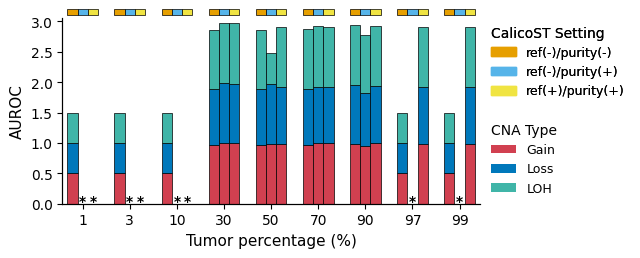

In [14]:
fig, ax = plot_metrics(df, metric = metric, figsize = (5, 2.7), fontsize = 10)

In [15]:
fn = os.path.join(out_dir, 'cna_prediction.%s.%s.png' % (with_ref, metric))
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')

### Plot AUPRC

In [16]:
metric = 'AUPRC'
df = dat[['tool', metric, 'cna_type', 'run_id']].copy()
df

,tool,AUPRC,cna_type,run_id
0,ref(+)/purity(+),0.981052,gain,90
1,ref(-)/purity(+),0.967939,gain,90
2,ref(-)/purity(-),0.976437,gain,90
3,ref(+)/purity(+),0.932741,loss,90
4,ref(-)/purity(+),0.873985,loss,90
5,ref(-)/purity(-),0.971887,loss,90
6,ref(+)/purity(+),0.905388,loh,90
7,ref(-)/purity(+),0.988697,loh,90
8,ref(-)/purity(-),0.981020,loh,90
9,ref(+)/purity(+),0.974269,gain,99


/tmp/pbs.1790203.xomics/ipykernel_45463/209479722.py:30: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


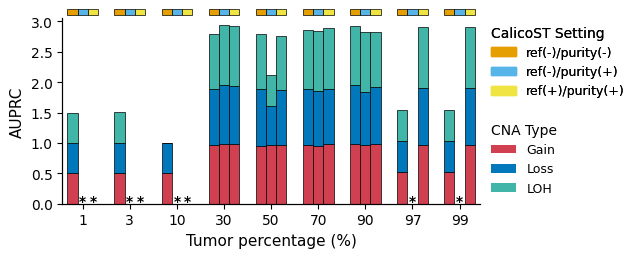

In [17]:
fig, ax = plot_metrics(df, metric = metric, figsize = (5, 2.7), fontsize = 10)

In [18]:
fn = os.path.join(out_dir, 'cna_prediction.%s.%s.png' % (with_ref, metric))
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')